# Flood · sub-peril family `[R/F/C]` — layer-0: the hazard definition (magnitude + source per sub-peril)

**Magnitude metric:** **inundation depth (ft above ground)** is the shared damage driver, but the *observed*
magnitude differs by sub-peril — riverine flood depth · pluvial 24-hr rainfall depth → modeled ponding · coastal
surge depth — each indexed by annual return period (10–500-yr) except coastal (hurricane category).

**Data source:** the products each sub-peril's pipeline reads — FEMA **BLE** depth grids + USGS **NLDI→NSS**
regression flow-frequency `[R]` · NOAA **Atlas 14** rainfall-frequency → SCS Curve-Number runoff `[F]` · NOAA
**SLOSH** surge `[C]`, shared from the hurricane peril — plus the screening/support layers (FEMA **NFHL** zones,
**EIA-860** asset registry, USGS **3DEP** DEM for ground elevation).

**What this notebook does:** states, up front and per sub-peril, **(a) the magnitude observable** and **(b) its
exact data source**, then shows the three reconverge on one damage driver (inundation depth at the asset). It fixes
the event basis (annual-maximum flood indexed by AEP / return period), the practical depth bound (sourced RP tail
+ equipment-submersion damage cap), the two-threshold structure (RP basis vs damage-onset depth), the event/severity
model (annual-max Monte Carlo + worse-source-wins sub-peril combine), the pre-integrated RP-depth surface, the
site-conditioned coupling placement, and the anchored depth-damage curve. This is an orientation layer above M0: it
does not fetch a grid, fit a frequency, or compute loss (those are M0→M4) — the depth-frequency and damage curves
here are schematic placeholders, and the one piece of real math (annual-max log-AEP interpolation) carries a
known-answer check. Every choice is provenance-tagged to a decision (`JD-FL-*`), an assumption (`AFL-*`), the Flood
Hazard-Data-Reference, or a named standard.

> Discipline: [*basics-spot-on*](../../../docs/principles/basics_spot_on.md) applied to the hazard's own
> definition — *say what we measure, and exactly where it comes from, before any modeling.*

> Plan-of-record: [`00_hazard_definition.md`](../../../docs/plans/flood/00_hazard_definition.md) · Decisions
> [`JD-FL-*`](../../../docs/plans/flood/decisions.md) · Assumptions [`AFL-*`](../../../docs/plans/flood/assumptions.md).

## 0 · Intent & scope

**Does:** orient the flood hazard **quantitatively** across its sub-peril family — the **magnitude observable per
sub-peril** (riverine flood depth · pluvial rainfall→ponding depth · coastal surge depth), each **paired with its
exact data source** (made prominent in §2); the **event basis** (annual-maximum flood at a
return period); the **practical depth bound**; the **two-threshold** structure (return-period basis vs damage-onset
*depth*); the **event/severity model** (annual-max MC + the research-backed sub-peril combine); the **pre-integrated
RP-depth surface** (profile-assembly, not a fit); the **coupling-taxonomy** placement (site-conditioned, for every
sub-peril); and the **anchored depth-damage curve** concept. Every choice is provenance-tagged.

**Does NOT:** fetch any grid, fit a frequency, or compute loss — those are M0→M4 (already built). The illustrative
depth-frequency curve and the schematic damage curve here are **orientation placeholders**: M1 reads the real BLE
depths / Atlas-14 rainfall, M3 builds the real `infrasure-damage-curves` depth-damage curve. This notebook fixes
the *definition the family shares*, not the fitted numbers.

**Provenance legend** (honesty discipline, per [`docs/references`](../../../docs/references/README.md)):
`[REF]` = an internal flood hazard-data reference · `[STD]` = a named external standard (Bulletin 17C, SCS
Curve Number, NOAA Atlas 14, SLOSH) · `[A]` = the competitive-research **A-series** spine (A12/A20/A21/A22) ·
`[JD]`/`[AFL]` = **our** logged decision / assumption (built, not inherited from the reference).

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

FT_TO_M = 0.3048
M_TO_FT = 1.0 / FT_TO_M
def m(ft):  return ft * FT_TO_M
def ft(m_): return m_ * M_TO_FT

## 1 · Why this layer exists — *one driver, three sub-perils, three sources*  (JD-FL-1, A12)

For hail and wildfire the **data product defined the event** and we inherited it; for **wind** no product did, so
we **authored** the event. Flood is a **third case**: the event *is* inherited (each sub-peril has its own product),
but **"flood" is not one peril** — the reference (`[REF]` §1) and the A-series (`[A]` A12) split it by a **dual
test** (*distinct footprint **and** distinct data*) into three sub-perils. Each one measures a **different magnitude**
from a **different source**, yet all three converge on the **same damage driver: inundation depth**. So the layer
that wind needed to *author* its single event, flood needs to **orient** its fragmented family:

In [2]:
why = pd.DataFrame([
    ("Hail",     "MRMS / MESH",        "“severe hail ≥ 1 in” — one event, one metric, baked in",            "INHERITED (1 product)"),
    ("Wildfire", "FSim (BP + FLP)",    "“fire + flame-length classes” — pre-integrated",                    "INHERITED (1 product)"),
    ("Wind",     "— none —",           "SPC · NOAA · ASCE · IEC · EF — fragmented, no event definition",     "AUTHORED (no product)"),
    ("Flood",    "3 products, 1 each", "[R] depth grid · [F] rainfall freq · [C] surge — 3 metrics, 3 srcs", "ORIENTED ← here"),
], columns=["peril", "data product(s)", "what defines the event", "layer-0 role"])
print(why.to_string(index=False))
print("\n→ Flood inherits its events (one product per sub-peril) but is a FAMILY of three. The job of this layer is")
print("  NOT to author an event (wind's job) — it is to state, up front and per sub-peril, WHAT we measure and")
print("  EXACTLY WHERE it comes from, then show they reconverge on one damage driver (depth). That is layer-0.")

   peril    data product(s)                                             what defines the event          layer-0 role
    Hail        MRMS / MESH             “severe hail ≥ 1 in” — one event, one metric, baked in INHERITED (1 product)
Wildfire    FSim (BP + FLP)                     “fire + flame-length classes” — pre-integrated INHERITED (1 product)
    Wind           — none —     SPC · NOAA · ASCE · IEC · EF — fragmented, no event definition AUTHORED (no product)
   Flood 3 products, 1 each [R] depth grid · [F] rainfall freq · [C] surge — 3 metrics, 3 srcs       ORIENTED ← here

→ Flood inherits its events (one product per sub-peril) but is a FAMILY of three. The job of this layer is
  NOT to author an event (wind's job) — it is to state, up front and per sub-peril, WHAT we measure and
  EXACTLY WHERE it comes from, then show they reconverge on one damage driver (depth). That is layer-0.


**The sub-peril family (the dual-test split).** `[A]` A12 / `[REF]` §1:

| Tag | Sub-peril | Footprint (distinct) | Data (distinct) | built |
|---|---|---|---|---|
| **[R]** | **Riverine** | river/stream network — the classic floodplain (slow-onset, large, well-gauged) | FEMA BLE depth grids + USGS flow-frequency | solar + wind |
| **[F]** | **Pluvial / flash** | local grid — intense-rainfall surface ponding, *often outside the floodplain* (the "blind spot") | NOAA Atlas 14 rainfall-frequency → modeled depth | solar + wind |
| **[C]** | **Coastal / surge** | coastline — surge + tide + wave + SLR | NOAA SLOSH MOM + RAFT (shared w/ hurricane) | built — Discovery/LA3 solar + Amazon wind (compound surge×wind) |

> **Coastal is built — via the hurricane cross-link** (JD-FL-12). Coastal surge is the **same storm** as a
> hurricane's wind, so it is **not** re-catalogued: each storm's surge (NOAA SLOSH MOM) is joined to that storm's
> hurricane wind on the reserved **`event_family_id`** (JD-FL-4) and combined **per subsystem** — one event,
> counted once. Built for **Discovery** (coastal solar) and the all-three sites **LA3** (solar) + **Amazon Wind**
> (wind); inland-only sites carry coastal = structural zero.

> **The honest framing.** Orientation is a *responsibility*: each sub-peril's magnitude **and** source must be
> **named and traceable** — §2 states each one prominently.

## 2 · The magnitude observable — *and its exact source* — PER SUB-PERIL  (JD-FL-6/9, AFL-6/P1)

**This is the heart of the layer.** The shared **damage** metric is **inundation depth** (`[REF]`:
*"depth is the universal metric — sample a depth grid at each asset and apply a depth-damage curve"*). But the
**magnitude we actually observe differs by sub-peril**, and so does **where it comes from**. Stating both, together,
per sub-peril, is the whole point of this layer:

In [3]:
# The magnitude observable + the EXACT data source, per sub-peril (paired, up-front).
obs = pd.DataFrame([
    ("[R] Riverine", "flood DEPTH above ground at a return period (ft → m)",
     "FEMA BLE depth grids (100/500-yr) — local-HEC-RAS quality, free, NAVD88",
     "JD-FL-6 / AFL-6"),
    ("[R] Riverine (lower RPs)", "depth at 10/25/50-yr (densified)",
     "USGS NLDI→NSS regional regression flow-frequency Q(T) + a BLE-anchored rating; 3DEP DEM for ground",
     "JD-FL-8 / AFL-12"),
    ("[F] Pluvial", "24-hr rainfall DEPTH at RP → modeled ponding depth",
     "NOAA Atlas 14 precip-frequency → SCS Curve-Number runoff → DEM/lidar ponding (NO free pluvial depth grid)",
     "JD-FL-9 / AFL-P1"),
    ("[C] Coastal (built)", "surge DEPTH per storm, by hurricane category",
     "NOAA SLOSH MOM + RAFT + HURDAT2 — shared w/ hurricane, joined on event_family_id",
     "JD-FL-12/14/15"),
], columns=["sub-peril", "magnitude observable", "EXACT data source (role)", "tracks"])
with pd.option_context("display.max_colwidth", 78, "display.width", 240):
    print(obs.to_string(index=False))
print("\nSCREENING / SUPPORT sources (which asset, where, how deep — not the depth itself):")
print("  • FEMA NFHL  — regulatory flood zones (1%/0.2% annual-chance): site SCREENING (is the asset in the SFHA?).")
print("  • EIA-860    — the asset registry: WHICH plants to screen (national, ~8.8k EIA-matched).")
print("  • 3DEP DEM / 1 m lidar — ground elevation: turns a water-surface elevation into DEPTH above the asset.")
print("\nTakeaway: ONE damage driver (depth), but THREE different observed magnitudes from THREE different products.")
print("Riverine MEASURES depth (BLE); pluvial MODELS depth from rainfall (no depth grid — the blind spot); coastal")
print("BORROWS depth from hurricane's surge. Naming the source per sub-peril is this layer's reason to exist.")

               sub-peril                                 magnitude observable                                                                                  EXACT data source (role)           tracks
            [R] Riverine flood DEPTH above ground at a return period (ft → m)                                   FEMA BLE depth grids (100/500-yr) — local-HEC-RAS quality, free, NAVD88  JD-FL-6 / AFL-6
[R] Riverine (lower RPs)                     depth at 10/25/50-yr (densified)        USGS NLDI→NSS regional regression flow-frequency Q(T) + a BLE-anchored rating; 3DEP DEM for ground JD-FL-8 / AFL-12
             [F] Pluvial   24-hr rainfall DEPTH at RP → modeled ponding depth NOAA Atlas 14 precip-frequency → SCS Curve-Number runoff → DEM/lidar ponding (NO free pluvial depth grid) JD-FL-9 / AFL-P1
     [C] Coastal (built)         surge DEPTH per storm, by hurricane category                          NOAA SLOSH MOM + RAFT + HURDAT2 — shared w/ hurricane, joined on event_family_id   JD-FL-12/1

**Provenance & the honest asymmetry across sources.**
- `[R]` **Riverine is the best-supported** (`[REF]` §5: *"best-supported sub-peril"*). BLE is a real measured
  depth product (HEC-RAS-quality); the only modeled link is the rating between the two BLE anchors (JD-FL-8).
- `[F]` **Pluvial is the blind spot** (`[REF]` §7): FEMA NFHL **under-maps it ~3×** (Wing/Bates ~41 M in the 1%
  floodplain vs FEMA ~13 M), and **no free pluvial *depth* product exists** — so we have easy *frequency* (Atlas 14
  rainfall) but must **model** depth with **nothing observed to calibrate against** (AFL-P1/P2 — flagged, not hidden).
- `[C]` **Coastal depth is obtainable** (SLOSH) but is the **same physical water as hurricane surge** — reuse one
  source, count it once (`[REF]` §7 "coastal overlaps hurricane surge").
- **Datum discipline** (`[REF]` §7): riverine BFEs (NAVD88), coastal levels (tidal datums), and asset elevations
  must reconcile to one datum (NOAA VDatum, AFL-13) or *every* depth is meaningless.

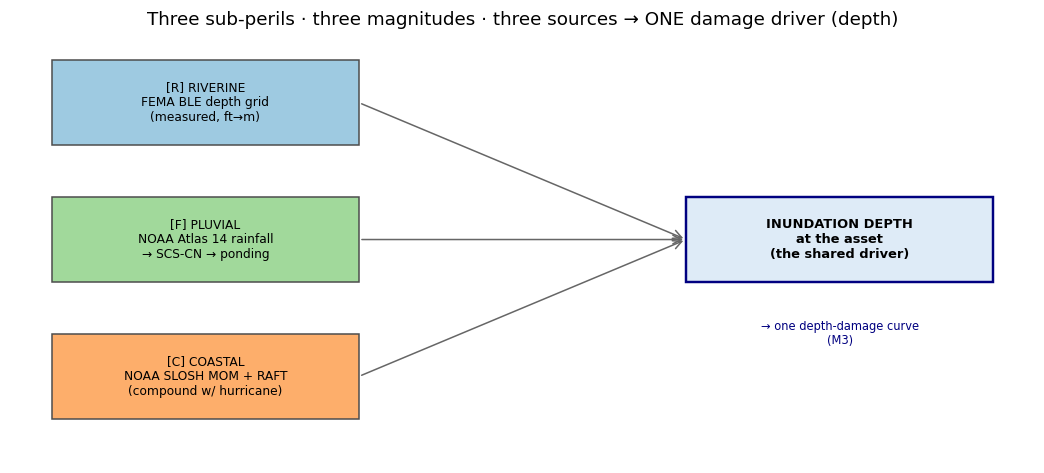

Each sub-peril speaks a different magnitude (flood depth / rainfall depth / surge depth) from a different
product, then reconverges on inundation depth at the asset — where ONE depth-damage curve closes the loop.


In [4]:
# A schematic: three different sources/magnitudes → one shared depth axis at the asset.
fig, ax = plt.subplots(figsize=(9.6, 4.4))
boxes = [
    (0.04, 0.74, "[R] RIVERINE\nFEMA BLE depth grid\n(measured, ft→m)", "#9ecae1"),
    (0.04, 0.42, "[F] PLUVIAL\nNOAA Atlas 14 rainfall\n→ SCS-CN → ponding", "#a1d99b"),
    (0.04, 0.10, "[C] COASTAL\nNOAA SLOSH MOM + RAFT\n(compound w/ hurricane)", "#fdae6b"),
]
for x, y, txt, c in boxes:
    ax.add_patch(plt.Rectangle((x, y), 0.30, 0.20, fc=c, ec="0.3"))
    ax.text(x + 0.15, y + 0.10, txt, ha="center", va="center", fontsize=8)
    ax.add_patch(FancyArrowPatch((x + 0.30, y + 0.10), (0.66, 0.42 + 0.10),
                                 arrowstyle="->", mutation_scale=14, color="0.4"))
ax.add_patch(plt.Rectangle((0.66, 0.42), 0.30, 0.20, fc="#deebf7", ec="navy", lw=1.6))
ax.text(0.81, 0.52, "INUNDATION DEPTH\nat the asset\n(the shared driver)", ha="center", va="center",
        fontsize=8.5, weight="bold")
ax.text(0.81, 0.30, "→ one depth-damage curve\n(M3)", ha="center", va="center", fontsize=7.5, color="navy")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off"); ax.grid(False)
ax.set_title("Three sub-perils · three magnitudes · three sources → ONE damage driver (depth)")
plt.tight_layout(); plt.show()
print("Each sub-peril speaks a different magnitude (flood depth / rainfall depth / surge depth) from a different")
print("product, then reconverges on inundation depth at the asset — where ONE depth-damage curve closes the loop.")

## 3 · The event / catalog basis — what counts as a flood event (for the annual loss)  (JD-FL-7, AFL-17)

A wind "event" crosses a magnitude line (μ); a **flood event** is framed differently. `[JD]` JD-FL-7 models flood
as **annual-maximum** — roughly **one damaging flood per year** — *not* a compound-Poisson multi-event stream
(which mis-fits flood). So "what counts" is the **year's worst flood**, indexed by its **annual-exceedance
probability (AEP) / return period**:

In [5]:
RP = pd.DataFrame([
    (10,   0.10,   "onset / frequent", "BLE 10% extent shows inundation begins; lower RPs densified (JD-FL-8)"),
    (25,   0.04,   "densified",        "regression Q(T) + BLE-anchored rating"),
    (50,   0.02,   "densified",        "regression Q(T) + BLE-anchored rating"),
    (100,  0.01,   "1% annual-chance", "FEMA BLE measured depth — the regulatory floodplain (anchor)"),
    (500,  0.002,  "0.2% annual-chance","FEMA BLE measured depth — the tail anchor"),
], columns=["return_period_yr", "AEP", "role", "source"])
print(RP.to_string(index=False))
print("\n[JD-FL-7] The event basis is ANNUAL-MAXIMUM: each simulated year draws AEP ~ U(0,1), reads loss(AEP) off the")
print("loss-exceedance curve → one per-year loss → the shared EAL/VaR/PML/TVaR. The catalog 'counts' the year's worst")
print("flood, indexed by AEP — the analogue of wind's μ-crossing, specialized to slow-onset annual-max flooding.")
print("[REF] FFRD targets a graduated ~5-yr…~2000-yr floodplain; FEMA BLE gives the 1% + 0.2% anchors we build on.")

 return_period_yr   AEP               role                                                                source
               10 0.100   onset / frequent BLE 10% extent shows inundation begins; lower RPs densified (JD-FL-8)
               25 0.040          densified                                 regression Q(T) + BLE-anchored rating
               50 0.020          densified                                 regression Q(T) + BLE-anchored rating
              100 0.010   1% annual-chance          FEMA BLE measured depth — the regulatory floodplain (anchor)
              500 0.002 0.2% annual-chance                             FEMA BLE measured depth — the tail anchor

[JD-FL-7] The event basis is ANNUAL-MAXIMUM: each simulated year draws AEP ~ U(0,1), reads loss(AEP) off the
loss-exceedance curve → one per-year loss → the shared EAL/VaR/PML/TVaR. The catalog 'counts' the year's worst
flood, indexed by AEP — the analogue of wind's μ-crossing, specialized to slow-onset annual-max flood

## 4 · The practical depth bound — where the magnitude distribution effectively ends  (AFL-W8, JD-FL-W2)

Wind truncates at a physical gust ceiling L; **flood depth is bounded differently** — by **two** practical caps,
not one open-ended physical maximum:

1. **The RP tail we can source.** The free measured product (FEMA BLE) stops at the **0.2% (500-yr)** depth; FFRD
   reaches ~2000-yr but is pilot-only. So the *evidenced* magnitude distribution effectively ends at the 500-yr
   depth — beyond it is bounded extrapolation (JD-FL-7), flagged, not fabricated.
2. **The damage saturates first.** Long before any "maximum depth," the **damage curve caps**: once the vulnerable
   equipment is fully submerged, deeper water adds no loss. For the wind asset this cap is **~28% of TIV even when a
   turbine is fully inundated** (rotor/nacelle/tower ride high above any flood — AFL-W8); for solar the inverter
   drowns shallow while panels survive. So the *loss* tail is short for a structural reason, regardless of depth.

So flood needs **no single physical L**: the sourced RP tail (500-yr) bounds the *frequency* side, and equipment
submersion bounds the *severity* side. Both are honest, both are logged.

In [6]:
print("[JD-FL-7]  evidenced RP tail   : 500-yr (0.2% AEP) BLE depth — beyond = bounded extrapolation, flagged")
print("[REF]      richer tail (future): FFRD ~2000-yr (pilot-only); commercial First Street/Fathom multi-RP")
print("[AFL-W8]   severity cap (wind) : ~28% of TIV at full turbine inundation (rotor/nacelle/tower flood-immune)")
print("[AFL-8]    severity cap (solar): inverter drowns @ ~0.75 ft (x0); elevated panels survive → curve caps low")
print("\nTakeaway: flood's 'upper bound' is NOT a single physical depth — it is (a) the deepest RP we can SOURCE and")
print("(b) the depth at which the vulnerable equipment is fully submerged and the damage curve flattens.")

[JD-FL-7]  evidenced RP tail   : 500-yr (0.2% AEP) BLE depth — beyond = bounded extrapolation, flagged
[REF]      richer tail (future): FFRD ~2000-yr (pilot-only); commercial First Street/Fathom multi-RP
[AFL-W8]   severity cap (wind) : ~28% of TIV at full turbine inundation (rotor/nacelle/tower flood-immune)
[AFL-8]    severity cap (solar): inverter drowns @ ~0.75 ft (x0); elevated panels survive → curve caps low

Takeaway: flood's 'upper bound' is NOT a single physical depth — it is (a) the deepest RP we can SOURCE and
(b) the depth at which the vulnerable equipment is fully submerged and the damage curve flattens.


## 5 · The TWO thresholds — keep them distinct (the part that trips newcomers)  (JD-FL-7, AFL-7, principle)

Exactly as for wind, flood has **two** thresholds living in different layers — and the flood version is on the
**depth** axis, which makes conflating them especially easy:

```
  FLOOD EVENT / RP BASIS                          ASSET DAMAGE-ONSET DEPTH
  "what the catalog COUNTS"  → annual loss (M4)    "where the depth-damage curve LEAVES ZERO" → anchors M3
  ─────────────────────────────────────────       ───────────────────────────────────────────────────────
  the year's worst flood, indexed by AEP           solar: inverter/pad height (x0 ≈ 0.75 ft → drowns shallow)
  (10/100/500-yr depth at the site)                wind:  pad elevation (turbine 0.30 m · substation 0.15 m)
```

A site can sit in the 1% floodplain (the catalog **counts** the flood) yet take **zero loss** if the water stays
below the equipment's pad/onset height. The depth-damage curve is **anchored** so `DR(depth ≤ onset) ≈ 0` and rises
only once water reaches the vulnerable component. **Most shallow flooding barely scratches well-sited equipment** —
the direct analogue of "most severe wind barely scratches a turbine."

In [7]:
PAD = pd.DataFrame([
    ("solar — inverter/electrical", 0.23, "x0 ≈ 0.75 ft single-axis horizontal stow (AFL-15); drowns shallow"),
    ("solar — panels (elevated)",   2.4,  "ride high → survive most floods; the height inversion"),
    ("wind — turbine pad",          0.30, "AFL-W6: node depth = max(flood − 0.30 m, 0)"),
    ("wind — substation pad",       0.15, "AFL-W6: lower pad → catches a trace where turbines shed it"),
], columns=["component", "onset_depth_m", "note"])
PAD["onset_depth_ft"] = ft(PAD["onset_depth_m"]).round(2)
with pd.option_context("display.max_colwidth", 60, "display.width", 200):
    print(PAD.to_string(index=False))
print("\n[AFL-7] Coupling = depth_at_asset = water_surface_elevation − ground_elevation(asset DEM). The RP basis (§3)")
print("stays with M1 (it sets the annual loss); the damage-onset DEPTH goes to M3 (it anchors the curve at DR≈0).")
print("Keeping them separate is the load-bearing discipline — the same two-threshold split wind uses, on depth.")

                  component  onset_depth_m                                                              note  onset_depth_ft
solar — inverter/electrical           0.23 x0 ≈ 0.75 ft single-axis horizontal stow (AFL-15); drowns shallow            0.75
  solar — panels (elevated)           2.40             ride high → survive most floods; the height inversion            7.87
         wind — turbine pad           0.30                       AFL-W6: node depth = max(flood − 0.30 m, 0)            0.98
      wind — substation pad           0.15        AFL-W6: lower pad → catches a trace where turbines shed it            0.49

[AFL-7] Coupling = depth_at_asset = water_surface_elevation − ground_elevation(asset DEM). The RP basis (§3)
stays with M1 (it sets the annual loss); the damage-onset DEPTH goes to M3 (it anchors the curve at DR≈0).
Keeping them separate is the load-bearing discipline — the same two-threshold split wind uses, on depth.


## 6 · The event / severity model — annual-max MC + the research-backed sub-peril combine  (JD-FL-7/11, AFL-17/P3)

Given the per-sub-peril depth-at-RP, how does flood become a per-year loss distribution the **shared
compound-Poisson/NegBin engine** consumes? `[JD]` Two settled pieces:

**1. Annual-maximum MC (JD-FL-7).** Build a **loss-exceedance curve** from the RP depths, then each simulated year
draws `AEP ~ U(0,1)` → `loss(AEP)` by **log-AEP interpolation** (bounded extrapolation below 0.002) → per-year
losses → EAL / VaR / PML / TVaR (% of TIV). By construction the percentiles **reproduce the BLE anchors** at
100/500-yr — a known-answer we verify below.

**2. Sub-peril combine = co-sample + worse-source-wins (JD-FL-11).** M4 combines riverine + pluvial into **one
inland** annual flood loss (the coastal stream is a separate compound-Poisson surge×wind event stream, summed on
top — JD-FL-12) — and the inland combine works **differently from wind on purpose**:

In [8]:
combine = pd.DataFrame([
    ("Occurrence", "co-sample COMONOTONIC", "one annual AEP u ~ U(0,1); read BOTH sub-peril curves at u — one shared storm"),
    ("Severity (headline)", "WORSE-SOURCE-WINS", "year loss = max(loss_riverine(u), loss_pluvial(u)) — same ground drowns once"),
    ("Severity (envelope)", "additive-capped", "min(TIV, L_r + L_p) recorded as the upper sensitivity bound (φ=0)"),
], columns=["axis", "rule", "why"])
with pd.option_context("display.max_colwidth", 74, "display.width", 220):
    print(combine.to_string(index=False))
print("\n[JD-FL-11] Backed by flood_subperil_research (Bates 2021 / Fathom 'max depth at each pixel'; FFRD shared-storm;")
print("Oasis LMF 'metrics on the combined per-year vector, never summed marginals').")
print("\n*** FLOOD MAXES; WIND ADDS — intentional. *** Flood sub-perils act on the SAME equipment with the SAME water,")
print("so a component drowns once → worse-source-wins (max). Convective-wind sub-perils (tornado vs strong-wind) hit")
print("DIFFERENT subsystems via DIFFERENT physics → their losses ADD. Same interface, opposite combine — by design.")

               axis                  rule                                                                           why
         Occurrence co-sample COMONOTONIC one annual AEP u ~ U(0,1); read BOTH sub-peril curves at u — one shared storm
Severity (headline)     WORSE-SOURCE-WINS  year loss = max(loss_riverine(u), loss_pluvial(u)) — same ground drowns once
Severity (envelope)       additive-capped             min(TIV, L_r + L_p) recorded as the upper sensitivity bound (φ=0)

[JD-FL-11] Backed by flood_subperil_research (Bates 2021 / Fathom 'max depth at each pixel'; FFRD shared-storm;
Oasis LMF 'metrics on the combined per-year vector, never summed marginals').

*** FLOOD MAXES; WIND ADDS — intentional. *** Flood sub-perils act on the SAME equipment with the SAME water,
so a component drowns once → worse-source-wins (max). Convective-wind sub-perils (tornado vs strong-wind) hit
DIFFERENT subsystems via DIFFERENT physics → their losses ADD. Same interface, opposite combine — by design.

In [9]:
# Known-answer check — log-AEP interpolation MUST reproduce the BLE anchor depths it is built from (JD-FL-7 frame).
# Illustrative riverine depths (m) at the sourced RPs (orientation placeholders; M1 reads the real BLE/regression).
rp_yr    = np.array([10, 25, 50, 100, 500])
aep      = 1.0 / rp_yr
depth_m  = np.array([0.00, 0.18, 0.34, 0.46, 0.60])      # ~Elizabeth BLE shape (JD-FL-3): 100-yr 0.46 / 500-yr 0.60

def depth_at_aep(u: float) -> float:
    """Year's flood depth by log-AEP interpolation of the RP curve (JD-FL-7). Monotone in depth as AEP falls."""
    return float(np.interp(np.log(u), np.log(aep[::-1]), depth_m[::-1]))

checks = {
    "reproduces 100-yr BLE depth (0.46 m)": np.isclose(depth_at_aep(0.01),  0.46),
    "reproduces 500-yr BLE depth (0.60 m)": np.isclose(depth_at_aep(0.002), 0.60),
    "monotone: deeper at rarer AEP":        depth_at_aep(0.002) > depth_at_aep(0.10),
    "onset ~0 at the 10-yr (AEP 0.10)":     depth_at_aep(0.10) < 0.05,
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "log-AEP interpolation failed a known-answer check (must reproduce its BLE anchors)"
print("\n  → The MC's depth(AEP) reproduces the measured BLE anchors exactly (PML@100/500 is anchored to real data);")
print("    EAL rests on the densified lower RPs (JD-FL-8). PML solid, EAL softer — logged honestly (JD-FL-7).")

  [PASS] reproduces 100-yr BLE depth (0.46 m)
  [PASS] reproduces 500-yr BLE depth (0.60 m)
  [PASS] monotone: deeper at rarer AEP
  [PASS] onset ~0 at the 10-yr (AEP 0.10)

  → The MC's depth(AEP) reproduces the measured BLE anchors exactly (PML@100/500 is anchored to real data);
    EAL rests on the densified lower RPs (JD-FL-8). PML solid, EAL softer — logged honestly (JD-FL-7).


> **Reuse the engine, specialize the bridge.** The shared MC is **untouched** — flood feeds it a per-year loss
> vector exactly as hail/wildfire/wind do (*standard interface, not standard physics*). What is flood-specific is
> the **annual-max** inland event model (the coastal stream *is* compound-Poisson) and the **worse-source-wins** inland combine. EAL is
> **additive** across sub-perils only loosely here (the headline maxes); the honest reporting is **marginals +
> combined headline + recorded envelope**, every metric off the **sampled** distribution (never expected-loss).

## 7 · The pre-integrated RP-depth surface — the severity tail, *already integrated*  (JD-FL-6/18, learning-09)

For riverine there is the same shortcut wind had with the ASCE surface: the EVT is **already done**. `[REF]`/`[A]`
the **FEMA BLE depth grids are pre-integrated return-period depth surfaces** (commercial First Street/Fathom are the same idea) — a hydraulic
model (HEC-RAS) already ran the probabilistic analysis and baked depth-by-return-period into the grid. Reading the
100-yr and 500-yr depth = **sampling the return-level curve at fixed exceedance probabilities** — exactly the
wildfire move (FSim pre-integrated the seasons) and governed by the same lesson:

In [10]:
print("[learning-09] If an upstream simulator pre-integrated the stochastic set into an annualized RP field, M1 is")
print("              PROFILE-ASSEMBLY (read the per-site profile), NOT extraction/fitting.")
print()
print("  RIVERINE : FEMA BLE depth grid  → depth at 1% (100-yr) + 0.2% (500-yr) — pre-integrated (READ, JD-FL-6)")
print("             lower RPs (10/25/50-yr) densified via regression Q(T) + BLE-anchored rating (JD-FL-8)")
print("  PLUVIAL  : NO pre-integrated depth grid exists (the blind spot) → MODEL depth from Atlas 14 rainfall")
print("             frequency via SCS-CN (JD-FL-9). Frequency is pre-integrated (Atlas 14); DEPTH is not.")
print("  COASTAL  : SLOSH MOM surge grids — pre-integrated, shared from hurricane (built — JD-FL-12)")
print()
print("[caveat] Pre-integration is a BORROW, not a free lunch (learning-09): we inherit FEMA/HEC-RAS's assumptions,")
print("vintage, datum, and resolution — the uncertainty moved upstream, it did not vanish. Riverine reads a real")
print("surface; pluvial has NO surface to read and must model — the cleanest statement of the sub-peril asymmetry.")

[learning-09] If an upstream simulator pre-integrated the stochastic set into an annualized RP field, M1 is
              PROFILE-ASSEMBLY (read the per-site profile), NOT extraction/fitting.

  RIVERINE : FEMA BLE depth grid  → depth at 1% (100-yr) + 0.2% (500-yr) — pre-integrated (READ, JD-FL-6)
             lower RPs (10/25/50-yr) densified via regression Q(T) + BLE-anchored rating (JD-FL-8)
  PLUVIAL  : NO pre-integrated depth grid exists (the blind spot) → MODEL depth from Atlas 14 rainfall
             frequency via SCS-CN (JD-FL-9). Frequency is pre-integrated (Atlas 14); DEPTH is not.
  COASTAL  : SLOSH MOM surge grids — pre-integrated, shared from hurricane (built — JD-FL-12)

[caveat] Pre-integration is a BORROW, not a free lunch (learning-09): we inherit FEMA/HEC-RAS's assumptions,
vintage, datum, and resolution — the uncertainty moved upstream, it did not vanish. Riverine reads a real
surface; pluvial has NO surface to read and must model — the cleanest statement of the sub

## 8 · A coupling-taxonomy primer — *how the hazard reaches the asset*  (AFL-3, A21, principle)

Defining "how deep" is half the job; the other half is **how the flood reaches the asset** (the *coupling*). The
platform sorts every peril into **three buckets** by footprint. **Flood is site-conditioned (bucket 3) for every
sub-peril** — the asset is never "missed" (if it is in the floodplain it floods); it reads its **own local depth**,
modulated by **micro-elevation (DEM)**. This reuses the **wildfire** site-conditioned M2 machinery:

In [11]:
buckets = pd.DataFrame([
    ("1. Areal hit-or-miss", "point / narrow path", "full loss IF hit, $0 if missed (bimodal)",
     "Bernoulli × Minkowski", "hail · tornado", "—"),
    ("2. Field-intensity", "regional field", "a local value, different every event",
     "sample the field per event", "HURRICANE (separate peril)", "hurricane ✅"),
    ("3. Site-conditioned", "broad swath (pre-integrated)", "its own local depth profile (no miss)",
     "depth field × elevation/height", "FLOOD — all sub-perils [R/F/C]", "wildfire + flood ✅"),
], columns=["bucket", "footprint", "what the asset reads", "math", "peril / sub-peril", "built?"])
with pd.option_context("display.max_colwidth", 38, "display.width", 200):
    print(buckets.to_string(index=False))
print("\nFLOOD → bucket 3 (site-conditioned) for EVERY sub-peril: depth field met against equipment height, DEM-")
print("modulated. NO Minkowski, NO hit-or-miss — micro-topography is load-bearing (a metre of elevation changes the")
print("depth). The asset-geometry difference is WITHIN the bucket, not across buckets:")
print("  • SOLAR  = dense areal polygon → AREAL inundated fraction × conditional depth (value ∝ area, AFL-14).")
print("  • WIND   = sparse turbine point-cloud → PER-NODE depth (each pad vs the flood surface; AFL-W2). Most")
print("             turbines sit on high ground → flood is a MINOR peril for wind (median project ~0% SFHA).")

              bucket                    footprint                     what the asset reads                           math              peril / sub-peril             built?
1. Areal hit-or-miss          point / narrow path full loss IF hit, $0 if missed (bimodal)          Bernoulli × Minkowski                 hail · tornado                  —
  2. Field-intensity               regional field     a local value, different every event     sample the field per event     HURRICANE (separate peril)        hurricane ✅
 3. Site-conditioned broad swath (pre-integrated)    its own local depth profile (no miss) depth field × elevation/height FLOOD — all sub-perils [R/F/C] wildfire + flood ✅

FLOOD → bucket 3 (site-conditioned) for EVERY sub-peril: depth field met against equipment height, DEM-
modulated. NO Minkowski, NO hit-or-miss — micro-topography is load-bearing (a metre of elevation changes the
depth). The asset-geometry difference is WITHIN the bucket, not across buckets:
  • SOLAR  = dense

**Cross-link note (no double-count, JD-FL-4/12).** Coastal `[C]` (surge) and pluvial `[F]` (rainfall) are **also
secondary perils of the hurricane**: a tropical cyclone drives surge **and** rainfall **and** river rise at once
(compound flooding). The reserved **`event_family_id`** (JD-FL-4) binds each TC-driven surge event to its parent
hurricane wind event so **one storm is counted once** — surge and wind combined **per subsystem**, not summed
across two pipelines. `[REF]` §7: *"use one surge source across both perils and avoid double-counting."* **Coastal
is built exactly this way** (JD-FL-12) — Discovery (solar) + Amazon Wind, joined to the hurricane peril.

## 9 · The anchored depth-damage curve concept — `DR(depth ≤ onset) ≈ 0`, rising with depth  (AFL-8/W8, A22)

The two thresholds (§5) make the depth-damage curve **anchored**: damage onset (the equipment pad/component height)
is *above* zero depth, so `DR ≈ 0` until water reaches the vulnerable component, then the curve rises and **caps**
at the submerged-equipment ceiling (§4). The curve below is **illustrative** — M3 builds the real
`infrasure-damage-curves` curve (RIVERINE_FLOOD × asset, capex-weighted, **source-agnostic** — one depth→damage path runs over riverine/pluvial/coastal alike; `x0` *is* the component-elevation onset).
It exists here to *show the shape the definition implies*:

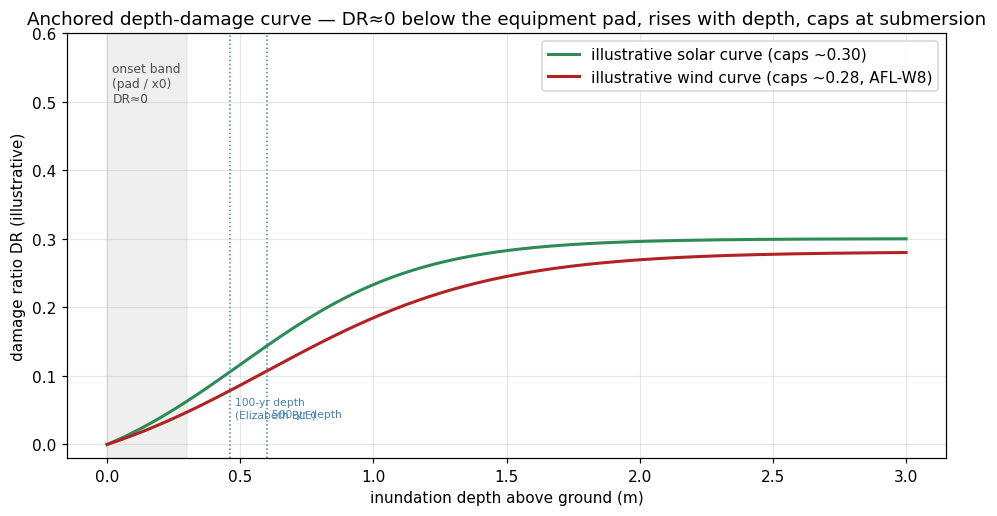

Takeaway: the gap between zero depth and the equipment ONSET (pad / x0) is the whole story — shallow floods do
~no damage; the curve leaves zero only when water reaches the vulnerable component, then CAPS once it is
submerged (panels/rotor ride high). This anchored, low-capping shape is the definition's M3 contract.


In [12]:
depth_m_axis = np.linspace(0, 3.0, 400)
def anchored_dr(d, onset, k, cap):
    raw = 1.0 / (1.0 + np.exp(-k * (d - onset)))
    raw = (raw - raw.min()) / (raw.max() - raw.min())     # anchor DR(0) → 0
    return cap * raw

dr_solar = anchored_dr(depth_m_axis, onset=0.5, k=3.0, cap=0.30)   # inverter drowns shallow, panels survive → caps low
dr_wind  = anchored_dr(depth_m_axis, onset=0.6, k=2.4, cap=0.28)   # AFL-W8: ~28% cap at full turbine inundation

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(depth_m_axis, dr_solar, lw=2, color="seagreen", label="illustrative solar curve (caps ~0.30)")
ax.plot(depth_m_axis, dr_wind,  lw=2, color="firebrick", label="illustrative wind curve (caps ~0.28, AFL-W8)")
ax.axvspan(0, 0.30, color="0.5", alpha=0.12)
ax.text(0.02, 0.5, "onset band\n(pad / x0)\nDR≈0", fontsize=8, color="0.3")
for d, lab in [(0.46, "100-yr depth\n(Elizabeth BLE)"), (0.60, "500-yr depth")]:
    ax.axvline(d, color="steelblue", ls=":", lw=1)
    ax.text(d + 0.02, 0.04, lab, fontsize=7, color="steelblue")
ax.set_xlabel("inundation depth above ground (m)"); ax.set_ylabel("damage ratio DR (illustrative)")
ax.set_title("Anchored depth-damage curve — DR≈0 below the equipment pad, rises with depth, caps at submersion")
ax.set_ylim(-0.02, 0.6); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
print("Takeaway: the gap between zero depth and the equipment ONSET (pad / x0) is the whole story — shallow floods do")
print("~no damage; the curve leaves zero only when water reaches the vulnerable component, then CAPS once it is")
print("submerged (panels/rotor ride high). This anchored, low-capping shape is the definition's M3 contract.")

## 10 · What graduates — the oriented layer-0 spec

This notebook fixes the definition the rest of the (already-built) pipeline consumes:

In [13]:
spec = pd.DataFrame([
    ("magnitude observable [R]", "flood DEPTH at RP (ft→m above ground)", "[REF]", "AFL-6"),
    ("  source [R]", "FEMA BLE 100/500-yr grids + USGS NLDI→NSS regression (lower RPs) + 3DEP DEM", "[REF]/[STD]", "JD-FL-6/8"),
    ("magnitude observable [F]", "24-hr rainfall DEPTH at RP → modeled ponding depth", "[REF]", "AFL-P1"),
    ("  source [F]", "NOAA Atlas 14 → SCS Curve Number → DEM/lidar ponding (NO free depth grid — blind spot)", "[STD]", "JD-FL-9"),
    ("magnitude observable [C]", "surge DEPTH per storm, by hurricane category (built)", "[REF]", "JD-FL-12"),
    ("  source [C]", "NOAA SLOSH MOM + RAFT + HURDAT2 — shared w/ hurricane, joined on event_family_id", "[REF]", "JD-FL-12/14"),
    ("screening / support", "FEMA NFHL (zones) · EIA-860 (which assets) · 3DEP DEM (ground)", "[REF]", "AFL-5/10"),
    ("event basis", "annual-maximum flood, indexed by AEP / return period", "[JD]", "JD-FL-7"),
    ("practical bound", "sourced RP tail (500-yr BLE) + equipment-submersion damage cap (~28% wind / low solar)", "[JD]", "AFL-W8"),
    ("two thresholds", "RP basis (counts the flood) vs damage-onset DEPTH (pad/x0 height) — kept distinct", "[JD]", "JD-FL-7"),
    ("severity / event model", "annual-max MC on the loss-exceedance curve; PML anchored to BLE", "[JD]", "JD-FL-7/AFL-17"),
    ("sub-peril combine", "co-sample comonotonic + worse-source-wins headline + additive envelope (flood MAXES)", "[JD]", "JD-FL-11"),
    ("pre-integrated tail", "BLE RP-depth grid = read (profile-assembly); pluvial has none → model", "[REF]", "JD-FL-6/learning-09"),
    ("coupling type", "site-conditioned (bucket 3) for all sub-perils; depth × elevation, DEM-modulated", "[A]", "AFL-3/A21"),
    ("damage curve", "anchored at component pad/x0 (DR≈0), rises with depth, caps at submersion", "[A]", "AFL-8/W8"),
], columns=["item", "definition", "provenance", "tracks"])
with pd.option_context("display.max_colwidth", 78, "display.width", 240):
    print(spec.to_string(index=False))

                    item                                                                             definition  provenance              tracks
magnitude observable [R]                                                  flood DEPTH at RP (ft→m above ground)       [REF]               AFL-6
              source [R]            FEMA BLE 100/500-yr grids + USGS NLDI→NSS regression (lower RPs) + 3DEP DEM [REF]/[STD]           JD-FL-6/8
magnitude observable [F]                                     24-hr rainfall DEPTH at RP → modeled ponding depth       [REF]              AFL-P1
              source [F] NOAA Atlas 14 → SCS Curve Number → DEM/lidar ponding (NO free depth grid — blind spot)       [STD]             JD-FL-9
magnitude observable [C]                                   surge DEPTH per storm, by hurricane category (built)       [REF]            JD-FL-12
              source [C]       NOAA SLOSH MOM + RAFT + HURDAT2 — shared w/ hurricane, joined on event_family_id       [REF]         JD-F

### Findings & carry-forward

- **Flood is oriented, not authored** — its events are inherited (one product per sub-peril), but the **family**
  needed an up-front map: the **magnitude observable and its exact source, per sub-peril** (§2) — now provided. The one piece of real math (the annual-max log-AEP interpolation) **passes its known-answer
  checks** (reproduces the BLE anchors, monotone in depth) — basics-spot-on for the definition.
- **One driver, three sources** — inundation depth is shared, but riverine **measures** it (FEMA BLE), pluvial
  **models** it from rainfall (Atlas 14 → SCS-CN; the blind spot — no free depth grid), and coastal **borrows** it
  (SLOSH MOM, built as a compound surge×wind sub-peril joined to hurricane — JD-FL-12). Naming the source per sub-peril is this layer's whole reason to exist.
- **The two thresholds are on the depth axis** — the RP basis counts the flood; the damage-onset depth (pad / x0
  height) anchors the curve at `DR≈0`. Most shallow flooding barely scratches well-sited equipment; the curve caps
  at submersion (~28% wind / low solar).
- **Flood maxes, wind adds** — the sub-peril combine (worse-source-wins) is *intentionally* different from wind's
  additive combine, because flood sub-perils drown the **same** equipment with the **same** water.
- **Coupling is site-conditioned for all sub-perils** — reusing wildfire's M2; the asset difference (areal solar
  vs per-node wind) is *within* the bucket. Cross-link via `event_family_id` keeps coastal from
  double-counting against the hurricane peril (coastal is built this way — JD-FL-12; the pluvial cross-link is deferred).

**→ M0** ([`m0_input_data/`](../m0_input_data/README.md)): the real evidence already met this definition (FEMA NFHL
screen + BLE depth + 3DEP DEM ✅). **→ M1:** riverine = read the BLE RP surface + densify (JD-FL-8); pluvial =
Atlas 14 → SCS-CN ponding (JD-FL-9). **→ M3:** the anchored `infrasure-damage-curves` depth-damage curve.
**→ M4:** annual-max MC, sub-perils co-sampled + worse-source-wins, every metric off the **sampled** distribution,
**% of TIV** alongside dollars — never the expected-loss shortcut.